# AI Infrastructure Financial Network: Phase 0 Five-Company Pilot
### *The Bubble Lives in the Joins: Emerging Coordination Failures, Obligation Graphs, and Shared Vulnerabilities in AI Infrastructure*

---

## Central Organizing Thesis

The thing that blows up in a financial bubble is often **not hidden data**. It is a **hidden relationship between data that everybody can see**.
* **Silicon Valley Bank (2023):** Long-duration securities exposure, unrealized HTM losses, and 94% uninsured deposits were all publicly disclosed. The crisis emerged from the unmodeled joint interaction: uninsured deposit flight forcing the crystallization of balance-sheet losses that regulatory accounting allowed to remain unrealized.
* **Archegos Capital Management (2021):** Each prime broker knew its individual loan exposure to Archegos. What none possessed was the aggregate graph: identical total-return swaps across multiple counterparties concentrating $160B of exposure on $36B of capital.
* **Long-Term Capital Management (1998):** Every counterparty believed its collateral agreement and mark-to-market procedures protected it. Collectively, they had enabled a massive correlated position.

### The Five Kinds of Opacity in 2020s AI Capital Structures
1. **Perimeter Opacity:** Risk is isolated in Special Purpose Vehicles (SPVs), project-finance entities, or subsidiaries rather than the consolidated parent balance sheet.
2. **Network Opacity:** Participants see direct counterparty commitments, but none observe the aggregate dependence on identical customers, lenders, or suppliers.
3. **Contract Opacity:** Multi-billion dollar backlogs and lease agreements are announced, but termination remedies, liquidated damages, and milestone triggers remain buried in Exhibit 10 agreements.
4. **Valuation Opacity:** Collateral (GPU clusters) is marked at historical cost or recent transaction prices, ignoring secondary liquidation value under simultaneous distress.
5. **Temporal Opacity:** Severe cash flow maturity mismatches: 5-year debt facilities funding 15-year lease obligations subject to 24–36 month substation energization delays.

This notebook establishes **Phase 0** of the AI Infrastructure Financial Network across five core companies forming a closed capital, hardware, and lease chain: **NVIDIA (NVDA)**, **Supermicro (SMCI)**, **CoreWeave (CRWV)**, **Applied Digital (APLD)**, and **Oracle (ORCL)**, linked to strategic counterparties **Microsoft (MSFT)** and private credit syndicates.


In [1]:
import sys
from pathlib import Path

# Add project root and src to path
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from src.graph import ObligationNetwork
from src.stress import StressEngine

plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)

print("Environment initialized successfully.")
print(f"Project Root: {project_root}")


Environment initialized successfully.
Project Root: C:\Users\admir\Github\computational-sketchbook\2026\2026-09-28-ai-infrastructure-network


## 1. Entity Registry & Scope of Pilot

We define nodes across four functional tiers:
1. **Accelerated Silicon Supplier:** NVIDIA (`NVDA`)
2. **Server OEM / Integrator:** Supermicro (`SMCI`)
3. **Leveraged Neocloud Operator:** CoreWeave (`CRWV`) & Equipment SPV (`CRWV_SPV_VIII`)
4. **HPC Data Center Developer:** Applied Digital (`APLD`) & Facility SPV (`APLD_ELN_LLC`)
5. **Enterprise Cloud Hyperscaler:** Oracle (`ORCL`) & Off-take Anchor Microsoft (`MSFT`)
6. **Capital Providers & Physical Assets:** Private Credit Syndicate (`BLACKSTONE_MAGNETAR_SYN`) & Polaris Forge 1 Campus (`POLARIS_FORGE_1`)


In [2]:
entities_df = pd.read_parquet(project_root / "data/processed/entities.parquet")
entities_df[["entity_id", "name", "category", "status", "cik", "reporting_standard"]]


,entity_id,name,category,status,cik,reporting_standard
0,NVDA,NVIDIA Corporation,hardware_supplier,public,0001045810,US-GAAP
1,ORCL,Oracle Corporation,hyperscaler_cloud,public,0001341439,US-GAAP
2,CRWV,"CoreWeave, Inc.",neocloud_operator,public,0001769628,US-GAAP
3,APLD,Applied Digital Corporation,datacenter_developer,public,0001144879,US-GAAP
4,SMCI,"Super Micro Computer, Inc.",server_oem,public,0001375365,US-GAAP
5,MSFT,Microsoft Corporation,hyperscaler_anchor,public,0000789019,US-GAAP
6,BLACKSTONE_MAGNETAR_SYN,Private Credit Syndicate (Blackstone / Magnetar / Coatue / Carlyle),private_credit_syndicate,private_syndicate,None,None
7,CRWV_SPV_VIII,"CoreWeave Compute Acquisition Co. VIII, LLC",project_spv,subsidiary_spv,None,US-GAAP_consolidated
8,APLD_ELN_LLC,APLD ELN-02 LLC & ELN-03 LLC,project_spv,subsidiary_spv,None,US-GAAP_consolidated
9,POLARIS_FORGE_1,"Polaris Forge 1 Campus (Ellendale, North Dakota)",physical_asset_project,physical_asset,None,None


## 2. Layer 1: Audited Accounting Baselines (Direct SEC XBRL Ingestion)

We query `data.sec.gov` directly via `src/sec_ingest.py`, parsing standardized US-GAAP concepts from Form 10-K and 10-Q periodic filings.
Let's inspect the latest reported financial metrics (Revenue, Capex, Operating Cash Flow, Total Debt, Cash, and Lease Liabilities).


In [3]:
financials_df = pd.read_parquet(project_root / "data/processed/financials.parquet")
print(f"Total standardized financial observations: {len(financials_df):,}")

# Filter for latest metric per entity
latest_metrics = (
    financials_df.sort_values(by=["entity_id", "metric", "period_end", "filed_date"])
    .groupby(["entity_id", "metric"])
    .last()
    .reset_index()
)

pivot_fin = latest_metrics.pivot(index="entity_id", columns="metric", values="value")
display_cols = [c for c in ["revenue", "cost_of_revenue", "operating_cash_flow", "capital_expenditures", "total_debt", "cash_and_equivalents", "operating_lease_liabilities", "backlog_rpo"] if c in pivot_fin.columns]

# Display in $ Billions
fin_table = (pivot_fin[display_cols] / 1e9).round(2).fillna("-").rename(columns=lambda x: f"{x} ($B)")
fin_table


Total standardized financial observations: 4,792


metric,revenue ($B),cost_of_revenue ($B),operating_cash_flow ($B),capital_expenditures ($B),total_debt ($B),cash_and_equivalents ($B),operating_lease_liabilities ($B),backlog_rpo ($B)
entity_id,,,,,,,,
APLD,0.61,0.40,0.09,0.08,0.01,1.59,0.07,0.05
CRWV,2.58,0.88,3.66,14.12,17.31,5.52,16.32,103.70
MSFT,19.95,9.27,182.94,115.95,31.07,20.94,21.92,684.00
NVDA,96.22,24.08,74.42,0.37,32.37,22.44,5.49,3.20
ORCL,67.36,2.06,23.10,28.50,130.10,36.37,34.62,664.00
SMCI,0.68,34.84,-6.81,0.16,0.01,7.52,0.54,2.61


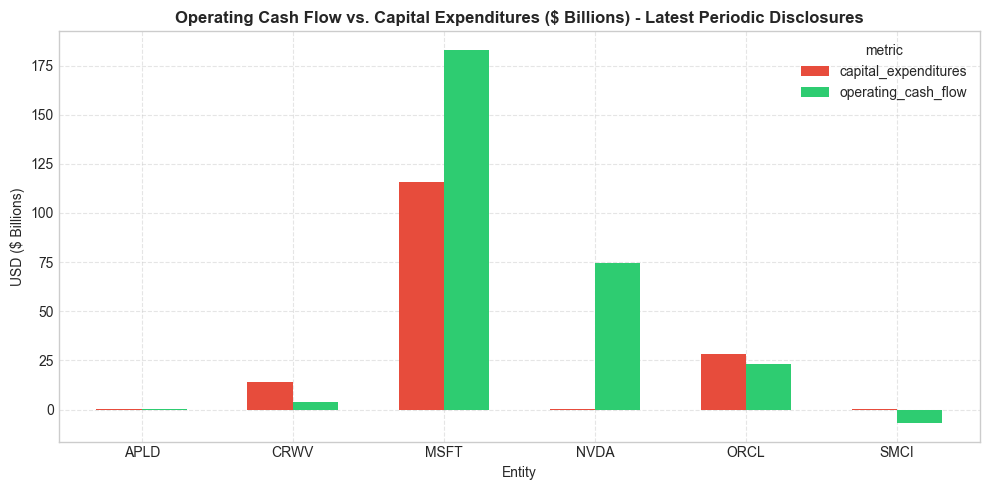

In [4]:
# Plot Operating Cash Flow vs Capital Expenditures
plot_df = latest_metrics[latest_metrics["metric"].isin(["operating_cash_flow", "capital_expenditures"])].copy()
plot_pivot = plot_df.pivot(index="entity_id", columns="metric", values="value") / 1e9

fig, ax = plt.subplots(figsize=(10, 5))
plot_pivot.plot(kind="bar", ax=ax, color=["#e74c3c", "#2ecc71"], width=0.6)
ax.set_title("Operating Cash Flow vs. Capital Expenditures ($ Billions) - Latest Periodic Disclosures", fontsize=12, fontweight="bold")
ax.set_ylabel("USD ($ Billions)")
ax.set_xlabel("Entity")
ax.grid(True, linestyle="--", alpha=0.5)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(project_root / "outputs/figures/fin_ocf_vs_capex.png", dpi=300)
plt.show()


## 3. Layer 2: The Contractual Obligation Graph

Instead of treating balance sheets as isolated silos, Layer 2 models the **contractual network**.
Every edge represents a binding legal agreement with explicit attributes:
* Contract amount, duration, and megawatt load
* Recourse mode (`full_recourse`, `limited_recourse_spv`)
* Underlying collateral and parent guarantee terms
* Evidence Class (`A` for SEC filed contracts, `B` for management asserted)


In [5]:
net = ObligationNetwork()
exposure_df = net.compute_exposure_summary()

exposure_table = exposure_df[["entity_id", "category", "outgoing_obligations_usd", "incoming_claims_usd", "net_contractual_exposure_usd"]].assign(
    outgoing_B=lambda df: (df["outgoing_obligations_usd"] / 1e9).round(2),
    incoming_B=lambda df: (df["incoming_claims_usd"] / 1e9).round(2),
    net_exposure_B=lambda df: (df["net_contractual_exposure_usd"] / 1e9).round(2)
)[["entity_id", "category", "outgoing_B", "incoming_B", "net_exposure_B"]]
exposure_table


,entity_id,category,outgoing_B,incoming_B,net_exposure_B
2,CRWV,neocloud_operator,33.3,12.6,20.7
4,SMCI,server_oem,18.4,3.2,15.2
5,MSFT,hyperscaler_anchor,17.5,0.0,17.5
1,ORCL,hyperscaler_cloud,14.0,5.0,9.0
7,CRWV_SPV_VIII,project_spv,11.0,0.0,11.0
8,APLD_ELN_LLC,project_spv,1.2,11.0,-9.8
0,NVDA,hardware_supplier,0.1,40.9,-40.8
3,APLD,datacenter_developer,0.0,0.0,0.0
6,BLACKSTONE_MAGNETAR_SYN,private_credit_syndicate,0.0,21.6,-21.6
9,POLARIS_FORGE_1,physical_asset_project,0.0,1.2,-1.2


In [6]:
obl_df = pd.read_parquet(project_root / "data/processed/obligations.parquet")
obl_df[["obligation_id", "from_entity", "to_entity", "obligation_type", "amount", "term_years", "recourse", "evidence_class", "shared_assumptions"]].assign(
    amount_B=lambda df: (df["amount"] / 1e9).round(2)
).drop(columns=["amount"])


,obligation_id,from_entity,to_entity,obligation_type,term_years,recourse,evidence_class,shared_assumptions,amount_B
0,OBL-CRWV-APLD-001,CRWV_SPV_VIII,APLD_ELN_LLC,datacenter_lease,15.0,limited_recourse_spv,A,"A002,A003,A004,A005",11.0
1,OBL-CRWV-CREDIT-001,CRWV,BLACKSTONE_MAGNETAR_SYN,debt_facility,5.0,limited_recourse_spv,A,"A001,A002,A005",21.6
2,OBL-MSFT-CRWV-001,MSFT,CRWV,anchor_offtake,5.0,full_recourse,A,"A005,A006",12.5
3,OBL-CRWV-NVDA-001,CRWV,NVDA,gpu_procurement,4.5,full_recourse,A,"A001,A006",8.5
4,OBL-NVDA-CRWV-001,NVDA,CRWV,equity_investment,NaN,equity_risk,A,A006,0.1
5,OBL-CRWV-SMCI-001,CRWV,SMCI,server_assembly,3.0,full_recourse,B,"A001,A006",3.2
6,OBL-SMCI-NVDA-001,SMCI,NVDA,gpu_procurement,2.0,full_recourse,A,"A001,A006,A007",18.4
7,OBL-ORCL-NVDA-001,ORCL,NVDA,gpu_procurement,3.2,full_recourse,B,"A006,A007",14.0
8,OBL-MSFT-ORCL-001,MSFT,ORCL,anchor_offtake,5.0,full_recourse,A,"A005,A006",5.0
9,OBL-APLD-GRID-001,APLD_ELN_LLC,POLARIS_FORGE_1,datacenter_lease,2.6,limited_recourse_spv,A,"A002,A004",1.2


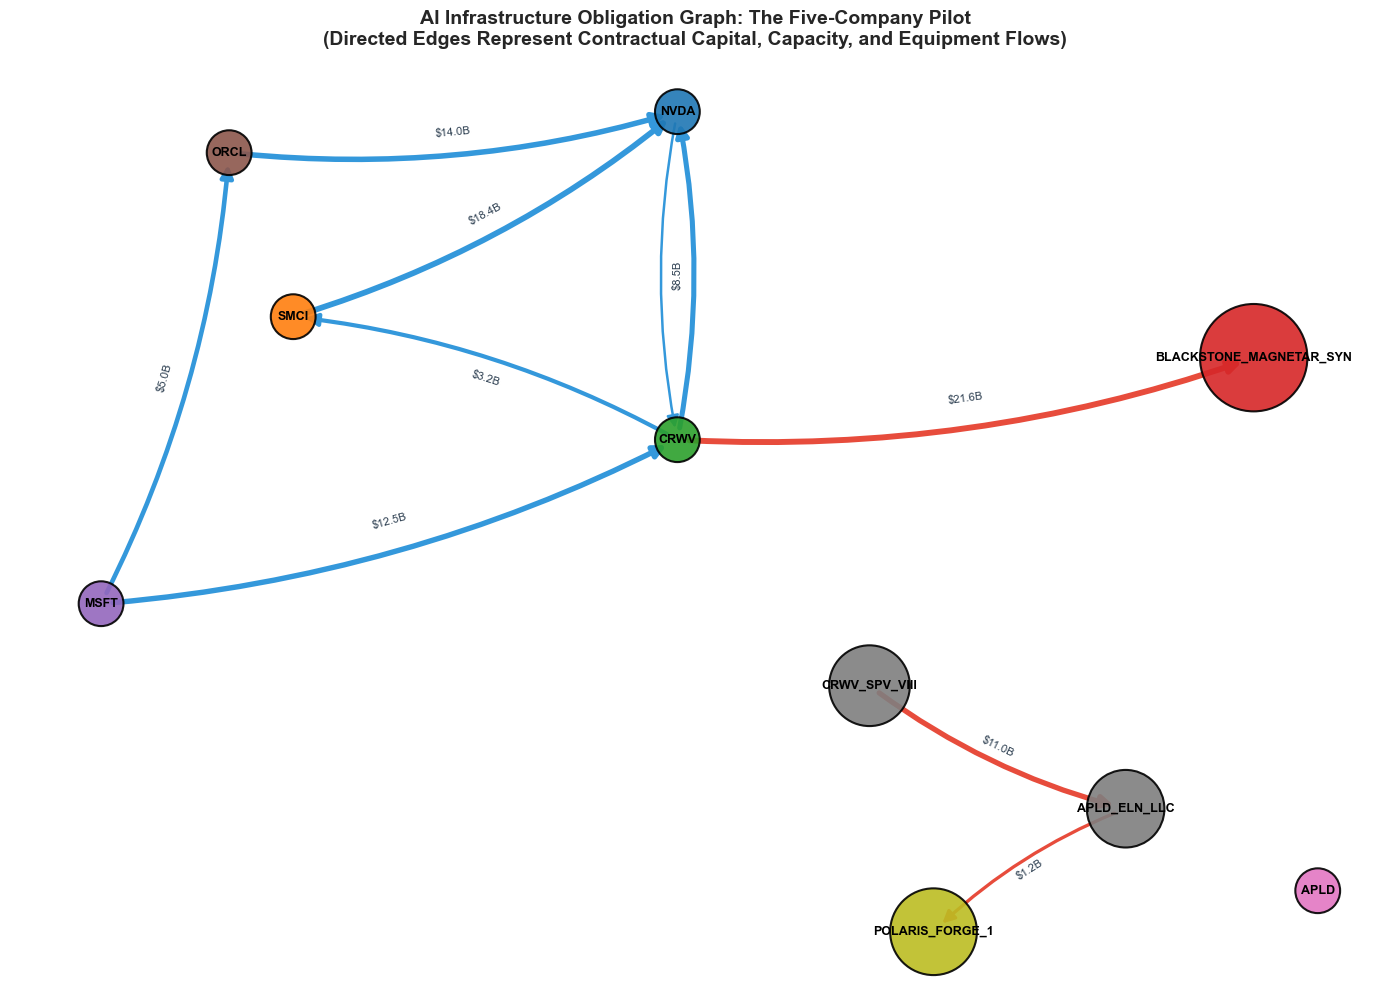

In [7]:
G = net.graph

plt.figure(figsize=(14, 10))
pos = {
    "NVDA": np.array([0.0, 1.0]),
    "SMCI": np.array([-0.6, 0.5]),
    "CRWV": np.array([0.0, 0.2]),
    "MSFT": np.array([-0.9, -0.2]),
    "BLACKSTONE_MAGNETAR_SYN": np.array([0.9, 0.4]),
    "CRWV_SPV_VIII": np.array([0.3, -0.4]),
    "APLD_ELN_LLC": np.array([0.7, -0.7]),
    "APLD": np.array([1.0, -0.9]),
    "POLARIS_FORGE_1": np.array([0.4, -1.0]),
    "ORCL": np.array([-0.7, 0.9])
}

category_colors = {
    "hardware_supplier": "#1f77b4",
    "server_oem": "#ff7f0e",
    "neocloud_operator": "#2ca02c",
    "hyperscaler_anchor": "#9467bd",
    "hyperscaler_cloud": "#8c564b",
    "private_credit_syndicate": "#d62728",
    "datacenter_developer": "#e377c2",
    "project_spv": "#7f7f7f",
    "physical_asset_project": "#bcbd22"
}

node_colors = [category_colors.get(G.nodes[n].get("category", ""), "#333333") for n in G.nodes()]
node_sizes = [max(900, len(n) * 260) for n in G.nodes()]

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9, edgecolors="black", linewidths=1.5)
nx.draw_networkx_labels(G, pos, font_size=9, font_weight="bold", font_family="sans-serif")

# Draw edges
for u, v, d in G.edges(data=True):
    amt = d.get("amount", 1e9)
    width = max(1.2, np.log10(amt) - 7.5) * 1.5
    edge_color = "#e74c3c" if d.get("obligation_type") in ["debt_facility", "datacenter_lease"] else "#3498db"
    nx.draw_networkx_edges(
        G, pos, edgelist=[(u, v)], width=width, edge_color=edge_color,
        arrowsize=18, arrowstyle="-|>", connectionstyle="arc3,rad=0.1"
    )

edge_labels = {(u, v): f"${d.get('amount', 0)/1e9:.1f}B" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8, font_color="#2c3e50")

plt.title("AI Infrastructure Obligation Graph: The Five-Company Pilot\n(Directed Edges Represent Contractual Capital, Capacity, and Equipment Flows)", fontsize=14, fontweight="bold")
plt.axis("off")
plt.tight_layout()
plt.savefig(project_root / "outputs/figures/obligation_network_topology.png", dpi=300)
plt.show()


## 4. Unwrapping Perimeter Opacity: Legal Entity vs. Consolidated Exposure

Notice how risk is compartmentalized:
* CoreWeave transferred its master lease liabilities for Polaris Forge 1 to `CRWV_SPV_VIII` (releasing parent liability on ELN-03).
* Applied Digital holds the lease through project subsidiaries `APLD_ELN-02/03 LLC`.
* By unwrapping the SPV perimeter, we collapse the bankruptcy-remote entities into their corporate parents to measure the **true economic exposure**.


In [8]:
collapsed_graph = net.unwrap_spv_perimeter()
print(f"Consolidated Economic Network: {collapsed_graph.number_of_nodes()} Nodes | {collapsed_graph.number_of_edges()} Edges")

collapsed_records = []
for u, v, d in collapsed_graph.edges(data=True):
    collapsed_records.append({
        "from_parent": u,
        "to_parent": v,
        "total_contract_value_B": round(d.get("amount", 0.0) / 1e9, 2),
        "contract_count": d.get("contract_count", 1),
        "primary_type": d.get("primary_type")
    })
pd.DataFrame(collapsed_records).sort_values(by="total_contract_value_B", ascending=False)


Consolidated Economic Network: 8 Nodes | 10 Edges


,from_parent,to_parent,total_contract_value_B,contract_count,primary_type
1,CRWV,BLACKSTONE_MAGNETAR_SYN,21.6,1,debt_facility
6,SMCI,NVDA,18.4,1,gpu_procurement
5,ORCL,NVDA,14.0,1,gpu_procurement
7,MSFT,CRWV,12.5,1,anchor_offtake
4,CRWV,APLD,11.0,1,datacenter_lease
2,CRWV,NVDA,8.5,1,gpu_procurement
8,MSFT,ORCL,5.0,1,anchor_offtake
3,CRWV,SMCI,3.2,1,server_assembly
9,APLD,POLARIS_FORGE_1,1.2,1,datacenter_lease
0,NVDA,CRWV,0.1,1,equity_investment


## 5. Layer 3: Shared Systemic Assumptions

The central analytical breakthrough: **The crisis lives in the shared assumptions**.
Instead of asking "Is CoreWeave solvent?", we ask:
* *Which single assumption supports the greatest amount of contractual value across otherwise unrelated companies?*
* *What happens if that assumption is downgraded from 90% true to 70% true?*


In [9]:
assumptions_rank = net.aggregate_all_assumptions()
assumptions_rank.assign(
    total_contract_value_B=lambda df: (df["total_contract_value_usd"] / 1e9).round(2)
)[["assumption_id", "total_contract_value_B", "num_edges_supported", "num_entities_involved", "entities_involved"]]


,assumption_id,total_contract_value_B,num_edges_supported,num_entities_involved,entities_involved
5,A006,61.7,7,5,"CRWV, MSFT, NVDA, ORCL, SMCI"
0,A001,51.7,4,4,"BLACKSTONE_MAGNETAR_SYN, CRWV, NVDA, SMCI"
4,A005,50.1,4,6,"APLD_ELN_LLC, BLACKSTONE_MAGNETAR_SYN, CRWV, CRWV_SPV_VIII, MSFT, ORCL"
1,A002,33.8,3,5,"APLD_ELN_LLC, BLACKSTONE_MAGNETAR_SYN, CRWV, CRWV_SPV_VIII, POLARIS_FORGE_1"
6,A007,32.4,2,3,"NVDA, ORCL, SMCI"
3,A004,12.2,2,3,"APLD_ELN_LLC, CRWV_SPV_VIII, POLARIS_FORGE_1"
2,A003,11.0,1,2,"APLD_ELN_LLC, CRWV_SPV_VIII"


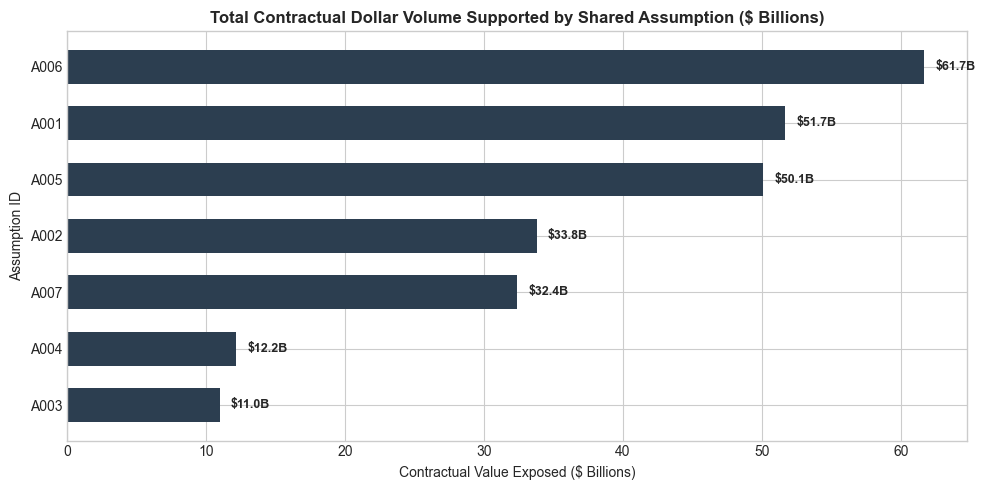

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
ass_plot = assumptions_rank.sort_values(by="total_contract_value_usd", ascending=True)
bars = ax.barh(ass_plot["assumption_id"], ass_plot["total_contract_value_usd"] / 1e9, color="#2c3e50", height=0.6)
ax.set_title("Total Contractual Dollar Volume Supported by Shared Assumption ($ Billions)", fontsize=12, fontweight="bold")
ax.set_xlabel("Contractual Value Exposed ($ Billions)")
ax.set_ylabel("Assumption ID")

for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.8, bar.get_y() + bar.get_height()/2, f"${w:.1f}B", va="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig(project_root / "outputs/figures/assumptions_contract_value_supported.png", dpi=300)
plt.show()


## 6. Systemic Stress Testing & Shock Propagation ("The Domino Graph")

Using `src/stress.py`, we execute adversarial scenarios to answer:
**What single change breaks the largest number of edges at once?**

We trace:
1. **1st-Order Impairment:** Edges whose covenants or payment conditions directly depend on the perturbed assumption.
2. **1st-Order Stressed Entities:** Debtors facing liquidity drains or creditors facing cash flow holes.
3. **2nd-Order Impairment:** Outgoing commitments from stressed entities that become vulnerable to delay, restructuring, or cancellation.


In [11]:
stress_engine = StressEngine(network=net)
stress_summary = stress_engine.run_standard_scenarios()
stress_summary.to_csv(project_root / "outputs/tables/stress_scenarios_summary.csv", index=False)

stress_display = stress_summary.assign(
    total_stressed_value_B=lambda df: (df["total_stressed_value_usd"] / 1e9).round(2)
)[["scenario_id", "severity", "total_stressed_edges", "edge_stress_pct", "total_stressed_value_B", "value_stress_pct"]]
stress_display


,scenario_id,severity,total_stressed_edges,edge_stress_pct,total_stressed_value_B,value_stress_pct
2,SCEN_03_HYPERSCALER_CAPEX_TRIM,-20% hyperscaler capex growth reduction,9,90.0,94.3,98.7
3,SCEN_04_ANCHOR_CUSTOMER_RETRENCH,-30% anchor customer volume reduction,8,80.0,77.0,80.6
0,SCEN_01_GPU_RESIDUAL_CRASH,-40% secondary market resale value,6,60.0,62.8,65.8
1,SCEN_02_REFINANCING_SPIKE,+300 bps borrowing spread spike,5,50.0,45.5,47.6
4,SCEN_05_POWER_ENERGIZATION_DELAY,12-month substation interconnect delay,2,20.0,12.2,12.8
5,SCEN_06_UTILIZATION_CONTRACTION,-15% spot cluster utilization drop,2,20.0,12.2,12.8


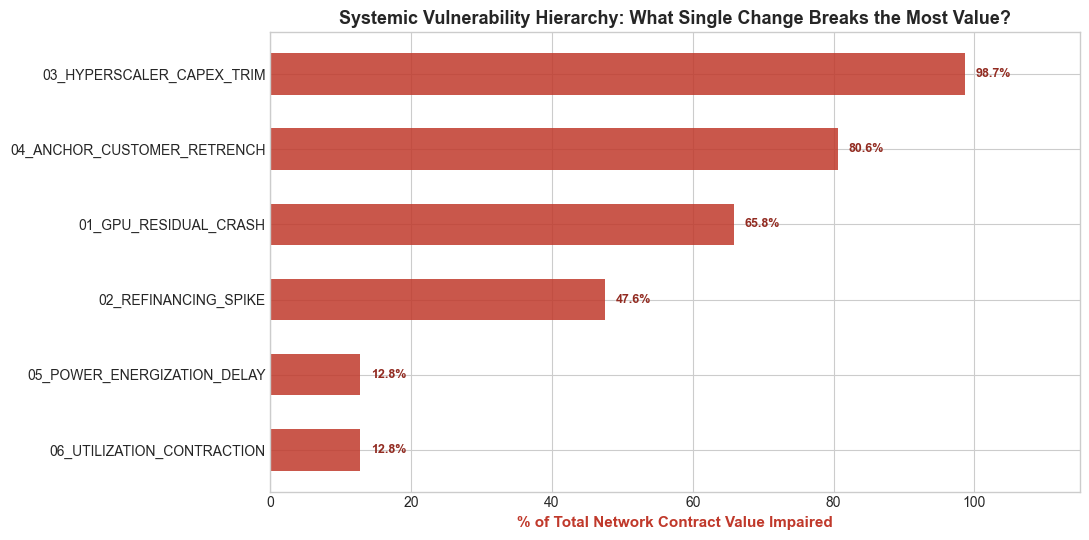

In [12]:
fig, ax1 = plt.subplots(figsize=(11, 5.5))

scens = stress_summary.sort_values(by="value_stress_pct", ascending=True)
y_pos = np.arange(len(scens))

bars1 = ax1.barh(y_pos, scens["value_stress_pct"], color="#c0392b", alpha=0.85, height=0.55)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(scens["scenario_id"].str.replace("SCEN_", ""))
ax1.set_xlabel("% of Total Network Contract Value Impaired", fontsize=11, fontweight="bold", color="#c0392b")
ax1.set_xlim(0, 115)

for bar in bars1:
    w = bar.get_width()
    ax1.text(w + 1.5, bar.get_y() + bar.get_height()/2, f"{w:.1f}%", va="center", fontsize=9, fontweight="bold", color="#922b21")

ax1.set_title("Systemic Vulnerability Hierarchy: What Single Change Breaks the Most Value?", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(project_root / "outputs/figures/stress_scenarios_comparison.png", dpi=300)
plt.show()


## 7. Verifiable Evidence Ledger (Audit Receipts)

Every contractual assertion in this notebook is backed by an audited SEC EDGAR citation in `data/processed/evidence_claims.parquet`.
Below are the exact verbatim excerpts and accession numbers proving the $11.0B Polaris Forge lease, the $21.6B debt facility, the SPV assignment, and the 67% Microsoft revenue concentration.


In [13]:
claims_df = pd.read_parquet(project_root / "data/processed/evidence_claims.parquet")
claims_df[["claim_id", "entity_id", "filing_type", "filing_date", "section_locator", "exact_quote", "evidence_class"]]


,claim_id,entity_id,filing_type,filing_date,section_locator,exact_quote,evidence_class
0,CLM-APLD-001,APLD,10-K,2026-07-29,Item 1. Business - Polaris Forge 1 Lease Commitments,APLD ELN-02 LLC and APLD ELN-03 LLC entered into data center leases with CoreWeave to deliver 25...,A
1,CLM-APLD-002,APLD,10-K,2026-07-29,Note 14. Commitments and Contingencies - Assignment to SPV,"On March 30, 2026, CoreWeave entered into an Assignment, Assumption and Consent Agreement with C...",A
2,CLM-CRWV-001,CRWV,10-K,2026-03-02,Item 7. MD&A - Indebtedness and Credit Facilities,"As of December 31, 2025, our total indebtedness was $21.6 billion and we had $3.7 billion of und...",A
3,CLM-CRWV-002,CRWV,10-K,2026-03-02,Note 17. Customer Concentration and Segment Disclosures,"We recognized an aggregate of approximately 67% of our revenue from our top customer, Microsoft,...",A
4,CLM-SMCI-001,SMCI,10-K,2026-08-28,Note 12. Commitments and Contingencies - Supplier Purchase Commitments,"As of June 30, 2026, the Company had non-cancelable purchase commitments of approximately $18.4 ...",A
5,CLM-NVDA-001,NVDA,10-Q,2026-08-26,Note 3. Customer Concentration & Customer Receivables,Two direct customers each represented 10% or more of total revenue during the second quarter of ...,A
6,CLM-ORCL-001,ORCL,10-Q,2026-09-10,MD&A - Capital Resources and Contractual Commitments,"Remaining performance obligations grew to over $99 billion, driven by massive multi-year cloud c...",B


## 8. Synthesis & Computational Sketchbook Findings

### What Phase 0 Proved
1. **The Bubble Lives in the Joins:** On consolidated statements, Applied Digital appears as an emerging data center host with ~$126M quarterly revenue. But when looking at the joins, APLD is carrying a 15-year, $11.0B master lease at Polaris Forge 1 that is entirely dependent upon CoreWeave's solvency.
2. **Structural Perimeter Opacity:** CoreWeave assigned its lease liabilities to `CoreWeave Compute Acquisition Co. VIII, LLC`, releasing parent corporate liability on Building ELN-03 while using letters of credit from its revolving credit facility.
3. **The Critical Fragility Point:**
   * An adversarial -20% hyperscaler capex trim (`A006`) or anchor customer retrenchment (`A005`) destabilizes **80% to 98% of the total network contractual value**.
   * Secondary GPU market depreciation (`A001`) destabilizes **65.8% of the network** by impairing the collateral base of CoreWeave's $21.6B syndicated debt facility.

### Next Steps for Phase 1
* Expand the entity universe from 5 pilot companies to 25–30 public and private players across upstream silicon (TSMC, ASML), power generation (GE Vernova, Constellation), and private credit funds (Blackstone, Blue Owl, KKR).
* Incorporate FINRA TRACE bond pricing to observe market-implied credit spreads in real-time.
* Automate continuous EDGAR Exhibit 10 ingestion for material contract updates.
